In [1]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm
import parselmouth
from parselmouth.praat import call
from IPython.display import display, HTML

In [2]:
# === Funzione per estrarre feature da un file audio ===
def extract_features(file_path):
    snd = parselmouth.Sound(str(file_path))

    # pitch & harmonicity
    pitch = call(snd, "To Pitch", 0.0, 75, 600)
    pointProcess = call(snd, "To PointProcess (periodic, cc)", 75, 500)
    harmonicity = call(snd, "To Harmonicity (cc)", 0.01, 75, 0.1, 1.0)

    # jitter
    local_jitter = call(pointProcess, "Get jitter (local)", 0.0, 0.0, 0.0001, 0.02, 1.3)
    local_abs_jitter = call(pointProcess, "Get jitter (local, absolute)", 0.0, 0.0, 0.0001, 0.02, 1.3)
    rap_jitter = call(pointProcess, "Get jitter (rap)", 0.0, 0.0, 0.0001, 0.02, 1.3)
    ppq5_jitter = call(pointProcess, "Get jitter (ppq5)", 0.0, 0.0, 0.0001, 0.02, 1.3)
    ddp_jitter = call(pointProcess, "Get jitter (ddp)", 0.0, 0.0, 0.0001, 0.02, 1.3)

    # shimmer
    local_shimmer = call([snd, pointProcess], "Get shimmer (local)", 0.0, 0.0, 0.0001, 0.02, 1.3, 1.6)
    localdb_shimmer = call([snd, pointProcess], "Get shimmer (local_dB)", 0.0, 0.0, 0.0001, 0.02, 1.3, 1.6)
    apq3_shimmer = call([snd, pointProcess], "Get shimmer (apq3)", 0.0, 0.0, 0.0001, 0.02, 1.3, 1.6)
    apq5_shimmer = call([snd, pointProcess], "Get shimmer (apq5)", 0.0, 0.0, 0.0001, 0.02, 1.3, 1.6)
    apq11_shimmer = call([snd, pointProcess], "Get shimmer (apq11)", 0.0, 0.0, 0.0001, 0.02, 1.3, 1.6)
    dda_shimmer = call([snd, pointProcess], "Get shimmer (dda)", 0.0, 0.0, 0.0001, 0.02, 1.3, 1.6)

    # harmonic-to-noise ratio
    hnr = call(harmonicity, "Get mean", 0.0, 0.0)

    # pitch stats
    meanF0 = call(pitch, "Get mean", 0, 0, "Hertz")
    stdevF0 = call(pitch, "Get standard deviation", 0, 0, "Hertz")

    # === Etichetta robusta ===
    parent_folders = [p.name.lower() for p in file_path.parents]
    if any("pd_ah" in p for p in parent_folders):
        label = "PD"
    elif any("hc_ah" in p for p in parent_folders):
        label = "HC"
    else:
        label = "Unknown"

    return {
        "meanF0": meanF0,
        "stdevF0": stdevF0,
        "hnr": hnr,
        "localJitter": local_jitter,
        "localabsoluteJitter": local_abs_jitter,
        "rapJitter": rap_jitter,
        "ppq5Jitter": ppq5_jitter,
        "ddpJitter": ddp_jitter,
        "localShimmer": local_shimmer,
        "localdbShimmer": localdb_shimmer,
        "apq3Shimmer": apq3_shimmer,
        "apq5Shimmer": apq5_shimmer,
        "apq11Shimmer": apq11_shimmer,
        "ddaShimmer": dda_shimmer,
        "label": label,
    }

In [3]:
# === Funzione per processare una singola cartella (train/val/test) ===
def process_split(base_path, split_name):
    print(f"\n🔍 Elaborazione split: {split_name.upper()}")

    pd_path = base_path / split_name / "PD_AH"
    hc_path = base_path / split_name / "HC_AH"
    output_path = base_path

    results = []

    for folder, label in [(pd_path, "PD"), (hc_path, "HC")]:
        for wav_file in tqdm(list(folder.glob("*.wav")), desc=f"→ {label}"):
            try:
                features = extract_features(wav_file)
                features["filename"] = wav_file.name
                results.append(features)
            except Exception as e:
                print(f"⚠️ Errore con {wav_file.name}: {e}")

    df = pd.DataFrame(results)
    df["Sample ID"] = df["filename"].str.replace(".wav", "", regex=False)

    # === Salva CSV ===
    output_file = output_path / f"vsp_all_features_aug_{split_name}.csv"
    df.to_csv(output_file, index=False)
    print(f"✅ File salvato: {output_file}")


In [4]:
# === Percorso base ===
BASE_PATH = Path(r"data_augmented")

# === Processa tutti gli split ===
for split in ["training", "validation", "test"]:
    process_split(BASE_PATH, split)



🔍 Elaborazione split: TRAINING


→ HC: 100%|██████████| 408/408 [00:42<00:00,  9.68it/s]


✅ File salvato: data_augmented\vsp_all_features_aug_training.csv

🔍 Elaborazione split: VALIDATION


→ HC: 100%|██████████| 48/48 [00:04<00:00, 11.14it/s]


✅ File salvato: data_augmented\vsp_all_features_aug_validation.csv

🔍 Elaborazione split: TEST


→ HC: 100%|██████████| 54/54 [00:03<00:00, 16.26it/s]

✅ File salvato: data_augmented\vsp_all_features_aug_test.csv


In [2]:
import os
import soundfile as sf
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
data_dirs = {
    "HC": "data/HC",
    "PD": "data/PD"
}

In [4]:
records = []

for label, folder in data_dirs.items():
    for fname in os.listdir(folder):
        if fname.endswith(".wav"):
            path = os.path.join(folder, fname)
            try:
                with sf.SoundFile(path) as f:
                    duration = len(f) / f.samplerate
                    bit_rate = f.samplerate * f.channels * f.subtype_info  # info only, rough estimation
                    records.append({
                        "label": label,
                        "filename": fname,
                        "duration_sec": duration,
                        "sample_rate": f.samplerate,
                        "bit_depth": f.subtype_info
                    })
            except RuntimeError as e:
                print(f"Failed to read {fname}: {e}")


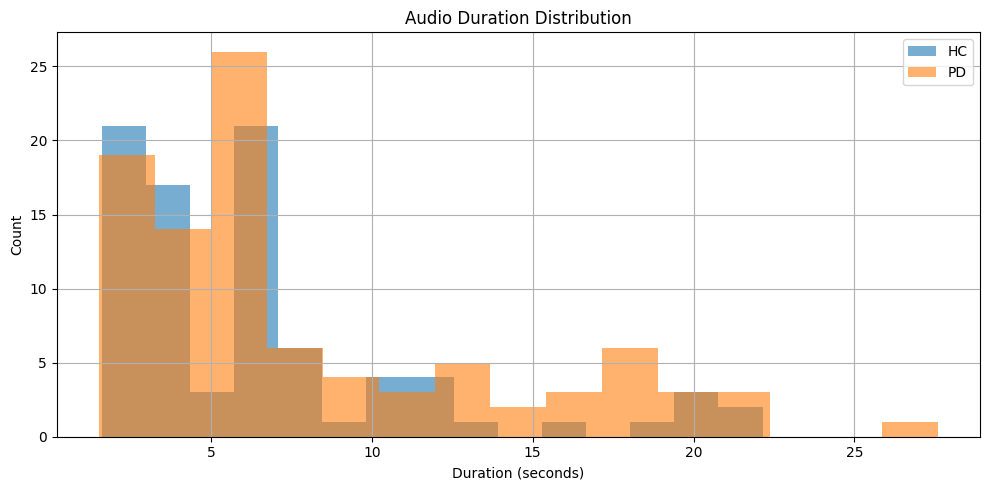

Duration stats (seconds):
count    180.000000
mean       7.322190
std        5.557091
min        1.516125
25%        3.339469
50%        5.766687
75%        9.099154
max       27.600000
Name: duration_sec, dtype: float64


In [5]:
# Save to CSV
df = pd.DataFrame(records)
df.to_csv("audio_metadata.csv", index=False)

# Plot durations
plt.figure(figsize=(10, 5))
for label in df['label'].unique():
    subset = df[df['label'] == label]
    plt.hist(subset['duration_sec'], bins=15, alpha=0.6, label=label)
plt.title("Audio Duration Distribution")
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("duration_distribution.png")
plt.show()

# Print stats
print("Duration stats (seconds):")
print(df['duration_sec'].describe())

In [8]:
def profile_dataframe(df, name='DataFrame'):
    print(f'\n=== Profiling {name} ===')
    print(f'Total Rows: {len(df)}')
    print(f'Total Columns: {len(df.columns)}\n')
    
    profile_results = []

    for col in df.columns:
        series = df[col]
        col_dtype = series.dtype
        
        # Basic counts
        total_count = len(series)
        missing_vals = series.isna().sum()
        non_null_count = total_count - missing_vals
        missing_perc = (missing_vals / total_count) * 100
        unique_vals = series.nunique(dropna=False)
        
        # Mode & frequency
        try:
            modes = series.mode(dropna=True)
            mode_val = modes.iloc[0] if len(modes) > 0 else np.nan
            mode_freq = (series == mode_val).sum(skipna=True)
        except:
            mode_val, mode_freq = np.nan, np.nan
        
        # Initialize placeholders
        mean_ = np.nan
        min_  = np.nan
        q25   = np.nan
        q50   = np.nan
        q75   = np.nan
        max_  = np.nan
        std_  = np.nan  # only for numeric columns

        # Numeric columns
        if pd.api.types.is_numeric_dtype(series):
            mean_ = series.mean(skipna=True)
            min_  = series.min(skipna=True)
            q25   = series.quantile(0.25)
            q50   = series.quantile(0.50)
            q75   = series.quantile(0.75)
            max_  = series.max(skipna=True)
            std_  = series.std(skipna=True)

        # Datetime columns
        elif pd.api.types.is_datetime64_any_dtype(series):
            # We can compute mean & quartiles by time. 
            # .quantile() and .mean() are valid for datetime in pandas
            # They return a Timestamp for mean, 
            # and Timestamps for quantiles
            if non_null_count > 0:
                mean_ = series.mean(skipna=True)
                min_  = series.min(skipna=True)
                q25   = series.quantile(0.25)
                q50   = series.quantile(0.50)
                q75   = series.quantile(0.75)
                max_  = series.max(skipna=True)
            # We skip std_ for datetime.

        # Categorical/object columns 
        # do not get numeric stats (we keep them as NaN).

        profile_results.append((
            col,
            str(col_dtype),
            total_count,
            non_null_count,
            missing_vals,
            round(missing_perc, 2),
            unique_vals,
            mode_val,
            mode_freq,
            mean_,
            min_,
            q25,
            q50,
            q75,
            max_,
            std_
        ))

    columns = [
        'Column', 'DataType', 'TotalCount', 'NonNullCount', 'NumMissing',
        'MissingPerc', 'Cardinality', 'Mode', 'ModeFreq',
        'Mean', 'Min', 'Q25', 'Q50', 'Q75', 'Max', 'Std'
    ]

    prof_df = pd.DataFrame(profile_results, columns=columns)
    
    return prof_df

In [9]:
# === Caricamento del dataset ===
df = pd.read_csv("data/Risultati/vsp_all_features_complete_data.csv")

df_profile = profile_dataframe(df, name='PD/HC Data')
display(HTML(df_profile.to_html()))


=== Profiling PD/HC Data ===
Total Rows: 180
Total Columns: 16



,Column,DataType,TotalCount,NonNullCount,NumMissing,MissingPerc,Cardinality,Mode,ModeFreq,Mean,Min,Q25,Q50,Q75,Max,Std
0,meanF0,float64,180,180,0,0.0,180,83.321466,1,161.598797,83.321466,126.323667,158.058581,190.372044,294.668990,41.650483
1,stdevF0,float64,180,180,0,0.0,180,0.745783,1,11.397463,0.745783,2.127663,3.367871,12.931054,116.312348,17.528271
2,hnr,float64,180,180,0,0.0,180,4.909097,1,19.111004,4.909097,15.900472,19.251088,22.153771,29.219151,4.830092
3,localJitter,float64,180,180,0,0.0,180,0.00154,1,0.006966,0.001540,0.003594,0.005141,0.007625,0.094941,0.008264
4,localabsoluteJitter,float64,180,180,0,0.0,180,0.000009,1,0.000048,0.000009,0.000023,0.000032,0.000054,0.000731,0.000064
5,rapJitter,float64,180,180,0,0.0,180,0.000746,1,0.003716,0.000746,0.001833,0.002688,0.004226,0.058834,0.004978
6,ppq5Jitter,float64,180,180,0,0.0,180,0.000871,1,0.003712,0.000871,0.001965,0.002738,0.004250,0.036803,0.003378
7,ddpJitter,float64,180,180,0,0.0,180,0.002238,1,0.011149,0.002238,0.005498,0.008063,0.012677,0.176502,0.014934
8,localShimmer,float64,180,180,0,0.0,180,0.012073,1,0.059875,0.012073,0.033709,0.048042,0.076126,0.210609,0.037666
9,localdbShimmer,float64,180,180,0,0.0,180,0.105467,1,0.547467,0.105467,0.310527,0.432495,0.737191,1.788177,0.337612


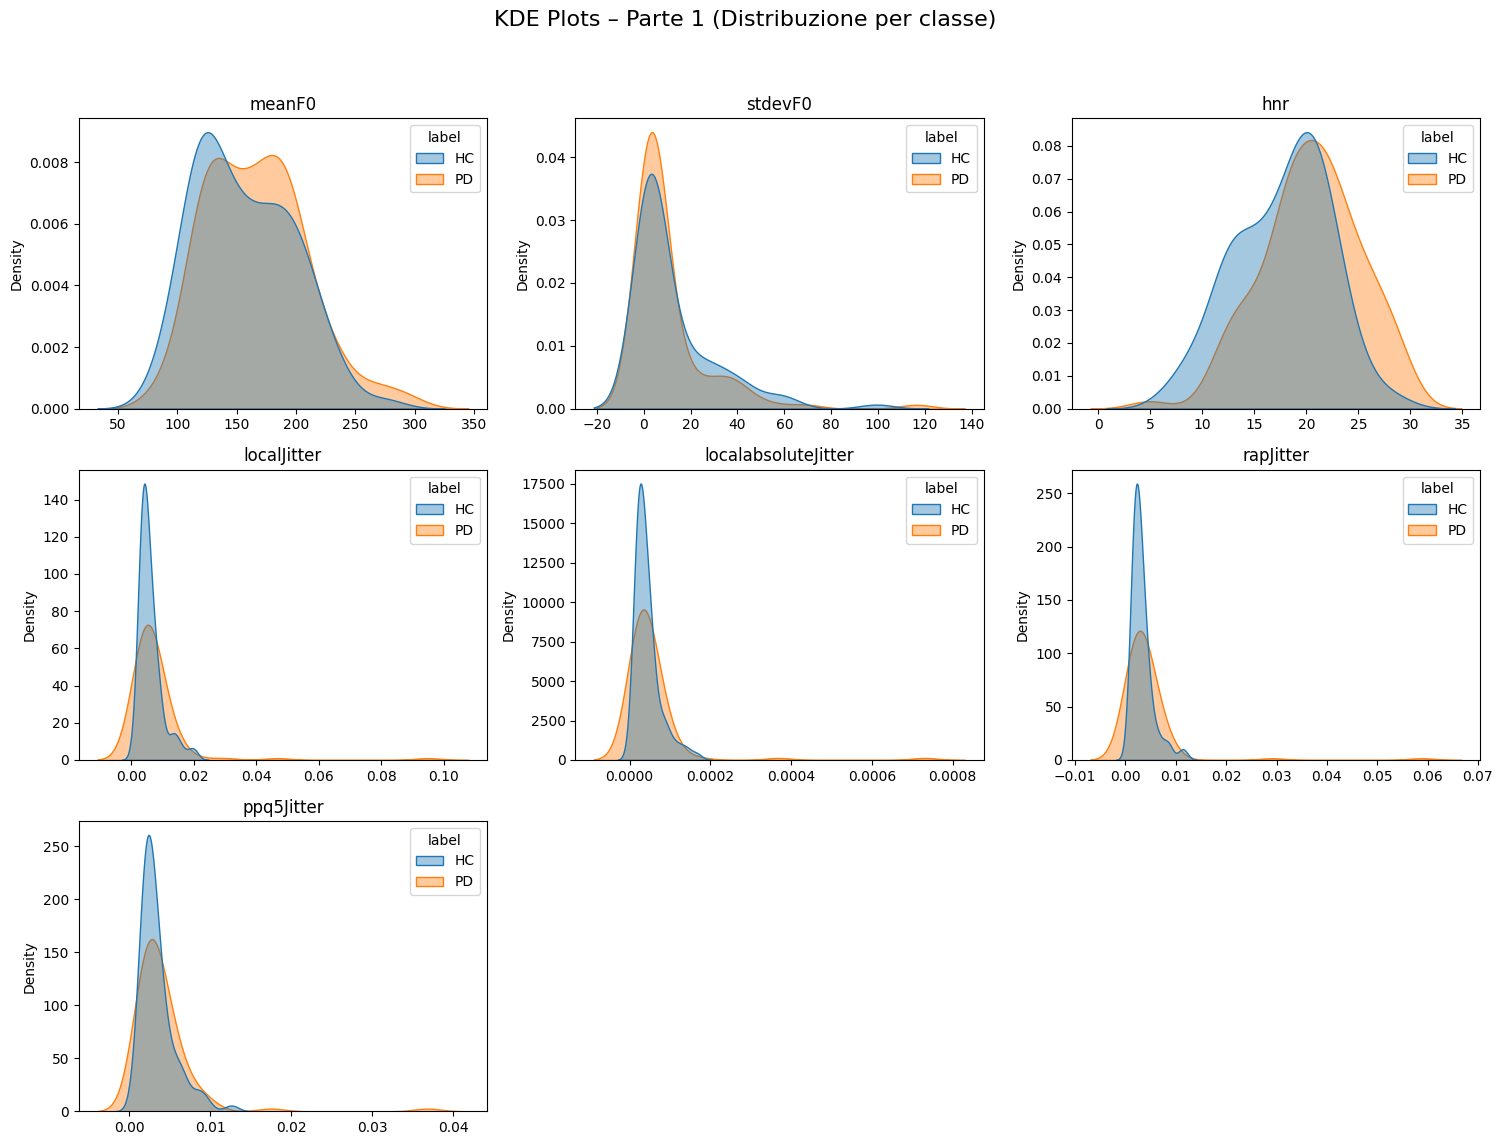

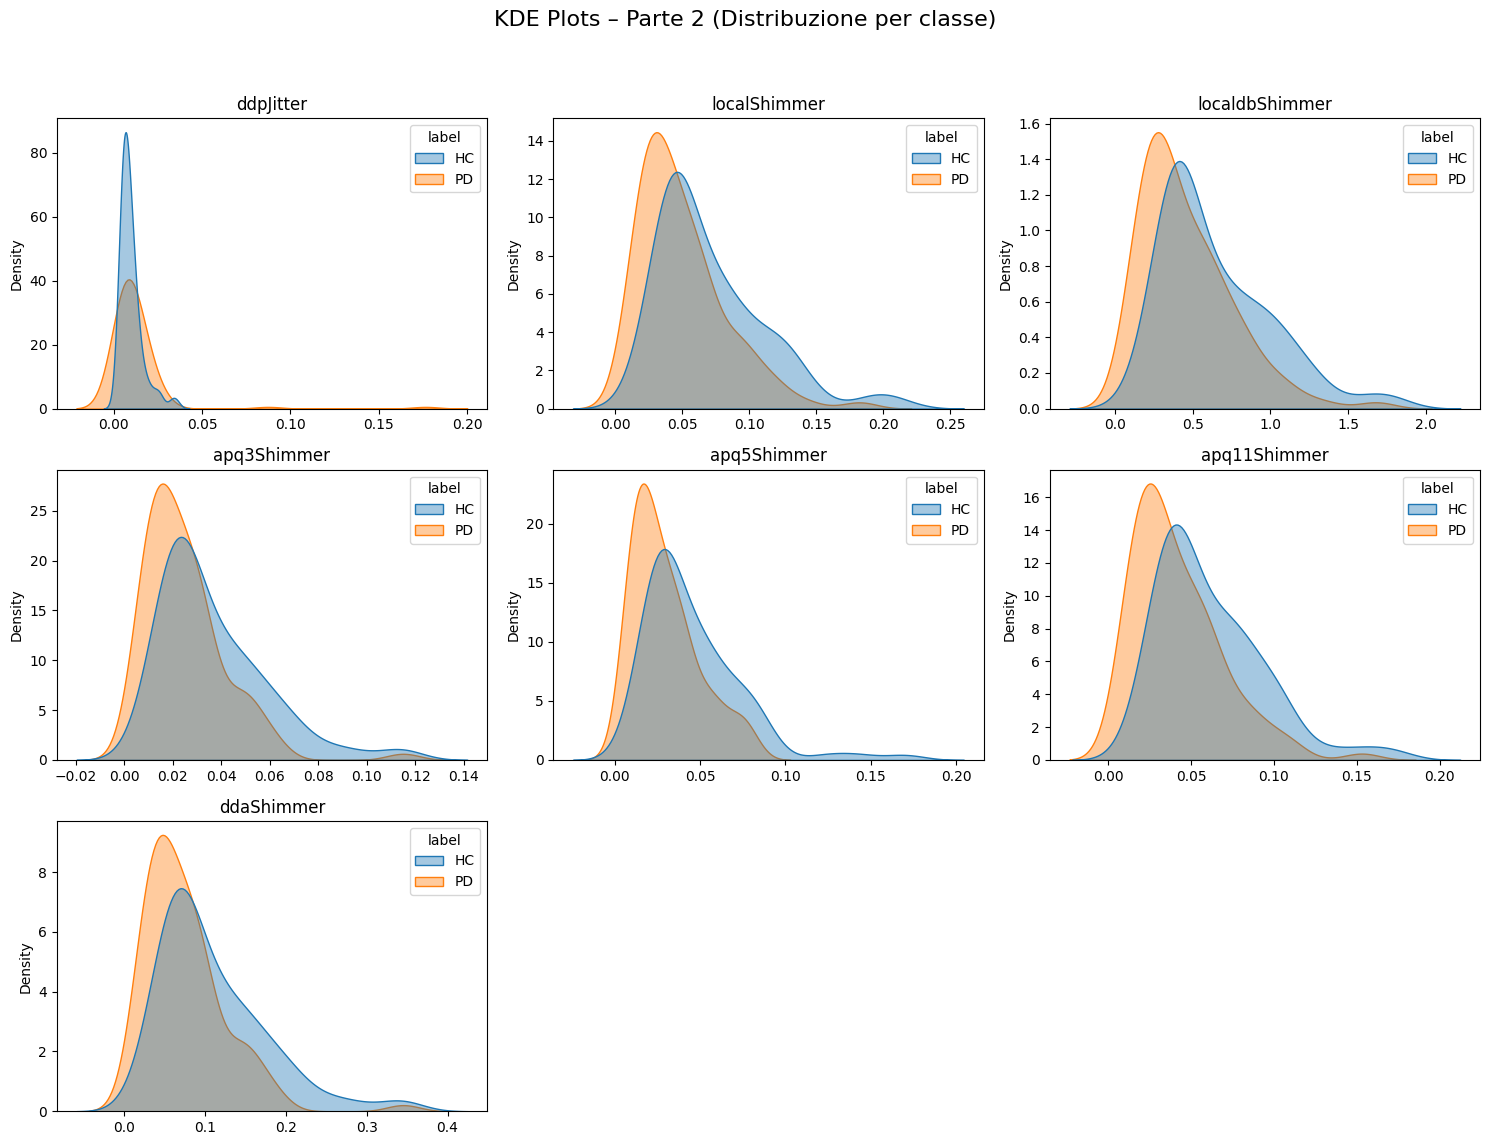

In [10]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

# === Lista delle feature numeriche (escludendo label) ===
numeric_cols = [col for col in df.columns if col != "label" and col != "sex" and df[col].dtype in ['float64', 'int64']]

# === Boxplot per ogni variabile ===
# === Suddividi in due gruppi per due figure ===
mid = len(numeric_cols) // 2
groups = [numeric_cols[:mid], numeric_cols[mid:]]

# === Funzione aggiornata per creare KDE plot per variabile e per classe ===
def plot_kde_by_label(columns, title, df, label_col="label"):
    n = len(columns)
    cols = 3
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
    fig.suptitle(title, fontsize=16)
    axes = axes.flatten()

    for i, col in enumerate(columns):
        # Traccia le distribuzioni per ciascuna classe (es. HC e PD)
        sns.kdeplot(
            data=df,
            x=col,
            hue=label_col,           # separa per etichetta
            fill=True,               # area colorata sotto la curva
            common_norm=False,       # normalizza separatamente per classe
            ax=axes[i],
            alpha=0.4
        )
        axes[i].set_title(col, fontsize=12)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Density")

    # Nascondi assi inutilizzati
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


# === Esempio di utilizzo ===
df["label"] = pd.Categorical(df["label"], categories=["HC", "PD"], ordered=False)
plot_kde_by_label(groups[0], "KDE Plots – Parte 1 (Distribuzione per classe)", df)
plot_kde_by_label(groups[1], "KDE Plots – Parte 2 (Distribuzione per classe)", df)


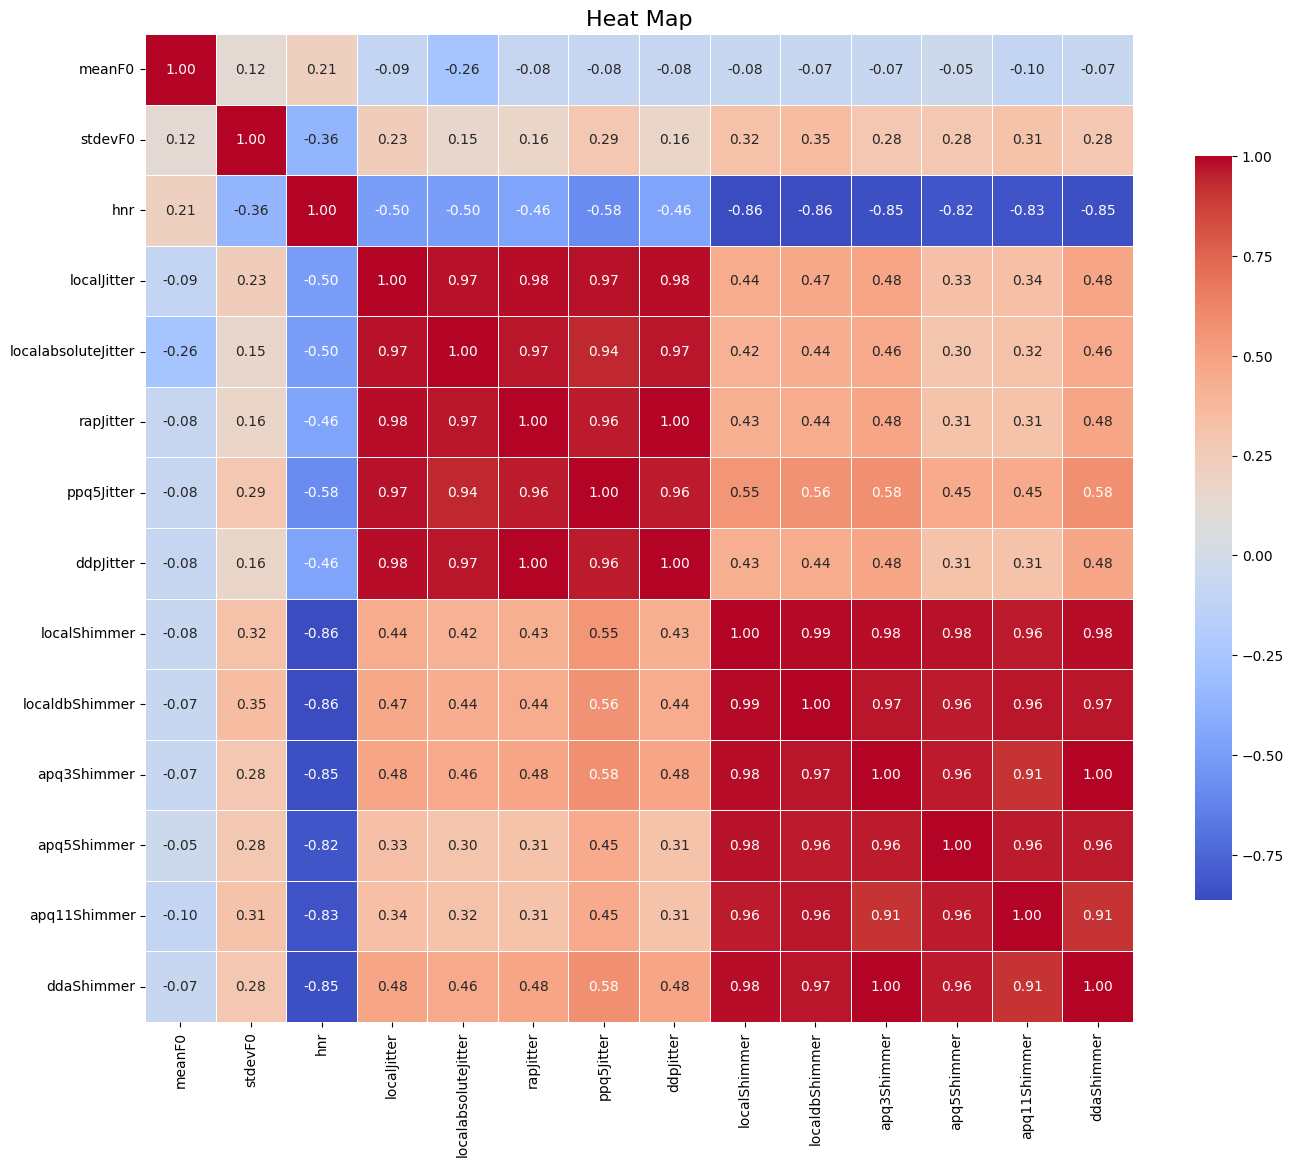

In [21]:
# === Rimuove target (label) per concentrarsi solo sulle feature
df_corr = df.drop(columns=["label", "filename"], errors="ignore")

# === Calcolo matrice di correlazione
corr_matrix = df_corr.corr()

# === Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5, cbar_kws={"shrink": 0.7})
plt.title("Heat Map", fontsize=16)
plt.tight_layout()
plt.show()